# 성능 비교 시각화 v3_2 — 2026-05-09

**담당:** 경이 (kyeongyi)  
**목적:** v3_1 데이터(15948행) 기준으로 Simple vs **KcELECTRA v3_2 (beomi/kcelectra-base)** 성능을 시각화.

> **[모델 명칭]**  
> KcELECTRA v3_2 = `beomi/kcelectra-base` (이준범 제작, 진짜 KcELECTRA)  
> KcELECTRA v3_1 = `monologg/koelectra-base-v3-discriminator` (KoELECTRA, 이름만 KcELECTRA였음)

## 실행 전 체크리스트
- [ ] `evaluate_compare_v3_2_20260509.py` 실행 완료 (Simple 평가)
- [ ] `data/20260509/eval_results_simple_v3_2_20260509.json` 존재
- [ ] `data/20260509/eval_results_kcelectra_v3_2_20260509.json` 존재 (Colab 완료 후)

## 생성 파일 (data/20260509/)
- `compare_macro_f1_v3_2_20260509.png` — Macro F1 막대 비교
- `compare_per_class_f1_v3_2_20260509.png` — 카테고리별 F1 비교
- `compare_confusion_matrix_v3_2_20260509.png` — Confusion Matrix 나란히
- `compare_radar_f1_v3_2_20260509.png` — 레이더 차트
- `compare_version_trend_v3_2_20260509.png` — 버전별 성능 추이 (v3 → v3_2)
- `compare_precision_recall_f1_v3_2_20260509.png` — Precision/Recall/F1 종합

In [2]:
# 셀 1: 경로 설정 + 데이터 로드
import json
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import platform
import seaborn as sns

# 한글 폰트 설정
if platform.system() == "Windows":
    matplotlib.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":
    matplotlib.rc("font", family="AppleGothic")
else:
    try:
        import subprocess
        import matplotlib.font_manager as fm
        subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)
        font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
        fm.fontManager.addfont(font_path)
        prop = fm.FontProperties(fname=font_path)
        matplotlib.rc("font", family=prop.get_name())
    except Exception:
        pass
matplotlib.rcParams["axes.unicode_minus"] = False

# 경로 설정 (로컬 / Colab 모두 지원)
_NB   = Path(".").resolve()
_BASE = _NB.parent if _NB.name == "notebooks" else _NB
OUT   = _BASE / "data" / "20260509"
OUT.mkdir(parents=True, exist_ok=True)

SIMPLE_JSON = OUT / "eval_results_simple_v3_2_20260509.json"
KC_JSON     = OUT / "eval_results_kcelectra_v3_2_20260509.json"

if not SIMPLE_JSON.exists():
    raise FileNotFoundError(f"{SIMPLE_JSON} 없음 -- evaluate_compare_v3_2_20260509.py 먼저 실행")

with open(SIMPLE_JSON, encoding="utf-8") as f:
    simple = json.load(f)

kc = None
if KC_JSON.exists():
    with open(KC_JSON, encoding="utf-8") as f:
        kc = json.load(f)
    print("[로드] KcELECTRA v3_2 결과 있음 (beomi/kcelectra-base)")
else:
    print("[주의] KcELECTRA v3_2 JSON 없음 -- Simple 결과만 시각화합니다.")
    print("  Colab에서 12_train_kcelectra_v3_2_20260509.ipynb 실행 후 재시도")

LABELS = ["일정", "준비물", "제출", "비용", "건강·안전", "기타"]

simple_f1 = simple["macro_f1"]
kc_f1     = kc["macro_f1"] if kc else None
delta     = kc_f1 - simple_f1 if kc else None

print(f"Simple v3_2 Macro F1: {simple_f1:.4f}")
if kc:
    print(f"KcELECTRA v3_2 (beomi) Macro F1: {kc_f1:.4f}")
    print(f"Delta: {delta:+.4f}")

[로드] KcELECTRA v3_2 결과 있음 (beomi/kcelectra-base)
Simple v3_2 Macro F1: 0.7590
KcELECTRA v3_2 (beomi) Macro F1: 0.8374
Delta: +0.0784


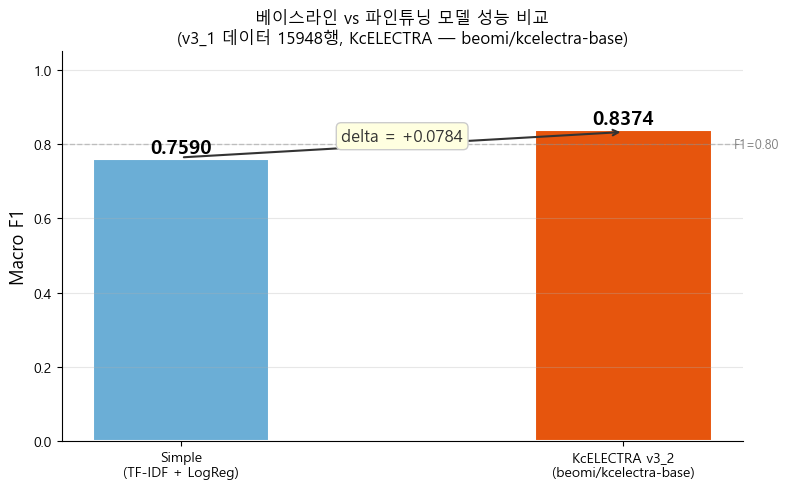

저장: C:\Users\kysop\Team_Project_Multiculture\multicultural-ai\model\classification\data\20260509\compare_macro_f1_v3_2_20260509.png


In [4]:
# 셀 2: [그래프 1] Macro F1 막대 비교 — 핵심 지표

if kc is None:
    print("KcELECTRA 결과가 없어 Simple 단독 시각화만 수행합니다.")
else:
    fig, ax = plt.subplots(figsize=(8, 5))

    models  = ["Simple\n(TF-IDF + LogReg)", "KcELECTRA v3_2\n(beomi/kcelectra-base)"]
    f1s     = [simple_f1, kc_f1]
    colors  = ["#6baed6", "#e6550d"]

    bars = ax.bar(models, f1s, color=colors, width=0.4, edgecolor="white", linewidth=1.5)

    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=14, fontweight="bold")

    ax.annotate("",
                xy=(1, kc_f1 - 0.005),
                xytext=(0, simple_f1 + 0.005),
                arrowprops=dict(arrowstyle="->", color="#333333", lw=1.5))
    mid_y = (simple_f1 + kc_f1) / 2
    ax.text(0.5, mid_y, f"delta = {delta:+.4f}",
            ha="center", va="bottom", fontsize=12, color="#333333",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="#cccccc"))

    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Macro F1", fontsize=13)
    ax.set_title("베이스라인 vs 파인튜닝 모델 성능 비교\n(v3_1 데이터 15948행, KcELECTRA — beomi/kcelectra-base)", fontsize=12)
    ax.axhline(y=0.8, color="gray", linestyle="--", alpha=0.4, linewidth=1)
    ax.text(1.25, 0.8, "F1=0.80", color="gray", fontsize=9, va="center")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    out_path = OUT / "compare_macro_f1_v3_2_20260509.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장: {out_path}")

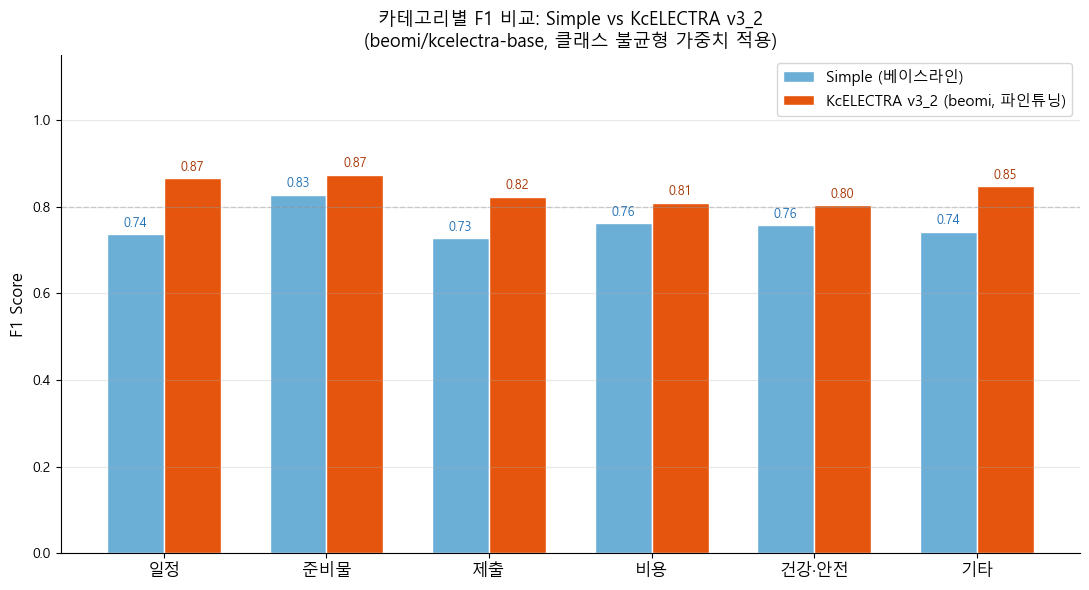

저장: C:\Users\kysop\Team_Project_Multiculture\multicultural-ai\model\classification\data\20260509\compare_per_class_f1_v3_2_20260509.png


In [5]:
# 셀 3: [그래프 2] 카테고리별 F1 비교 (grouped bar)

if kc is None:
    print("KcELECTRA 결과 없음 -- 스킵")
else:
    s_f1s = [simple["per_class"][lbl]["f1"] for lbl in LABELS]
    k_f1s = [kc["per_class"][lbl]["f1"] for lbl in LABELS]

    x = np.arange(len(LABELS))
    w = 0.35

    fig, ax = plt.subplots(figsize=(11, 6))
    bars1 = ax.bar(x - w/2, s_f1s, w, label="Simple (베이스라인)", color="#6baed6", edgecolor="white")
    bars2 = ax.bar(x + w/2, k_f1s, w, label="KcELECTRA v3_2 (beomi, 파인튜닝)", color="#e6550d", edgecolor="white")

    for bar in bars1:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}",
                ha="center", va="bottom", fontsize=9, color="#2171b5")
    for bar in bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}",
                ha="center", va="bottom", fontsize=9, color="#a63603")

    ax.set_xticks(x)
    ax.set_xticklabels(LABELS, fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("F1 Score", fontsize=12)
    ax.set_title("카테고리별 F1 비교: Simple vs KcELECTRA v3_2\n(beomi/kcelectra-base, 클래스 불균형 가중치 적용)", fontsize=13)
    ax.legend(fontsize=11)
    ax.axhline(y=0.8, color="gray", linestyle="--", alpha=0.3, linewidth=1)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    out_path = OUT / "compare_per_class_f1_v3_2_20260509.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장: {out_path}")

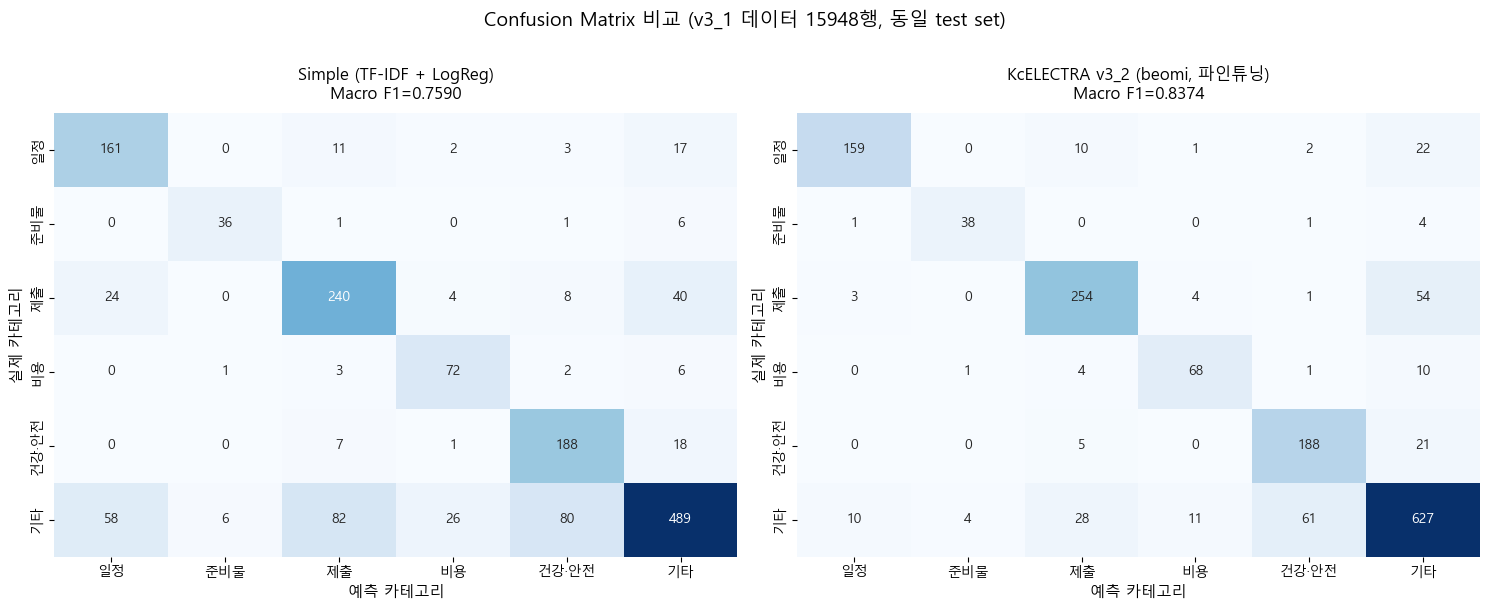

저장: C:\Users\kysop\Team_Project_Multiculture\multicultural-ai\model\classification\data\20260509\compare_confusion_matrix_v3_2_20260509.png


In [6]:
# 셀 4: [그래프 3] Confusion Matrix 나란히

if kc is None:
    print("KcELECTRA 결과 없음 -- Simple CM만 출력")
    s_cm = np.array(simple["confusion_matrix"])
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(s_cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, ax=ax, cbar=False)
    ax.set_xlabel("예측 카테고리", fontsize=11)
    ax.set_ylabel("실제 카테고리", fontsize=11)
    ax.set_title(f"Simple Confusion Matrix (Macro F1={simple_f1:.4f})", fontsize=12)
    plt.tight_layout()
    out_path = OUT / "confusion_matrix_simple_v3_2_20260509.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장: {out_path}")
else:
    s_cm = np.array(simple["confusion_matrix"])
    k_cm = np.array(kc["confusion_matrix"])

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for ax, cm_data, title in [
        (axes[0], s_cm, f"Simple (TF-IDF + LogReg)\nMacro F1={simple_f1:.4f}"),
        (axes[1], k_cm, f"KcELECTRA v3_2 (beomi, 파인튜닝)\nMacro F1={kc_f1:.4f}"),
    ]:
        sns.heatmap(cm_data, annot=True, fmt="d", cmap="Blues",
                    xticklabels=LABELS, yticklabels=LABELS,
                    ax=ax, cbar=False)
        ax.set_xlabel("예측 카테고리", fontsize=11)
        ax.set_ylabel("실제 카테고리", fontsize=11)
        ax.set_title(title, fontsize=12, pad=10)

    plt.suptitle("Confusion Matrix 비교 (v3_1 데이터 15948행, 동일 test set)", fontsize=14, y=1.01)
    plt.tight_layout()
    out_path = OUT / "compare_confusion_matrix_v3_2_20260509.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장: {out_path}")

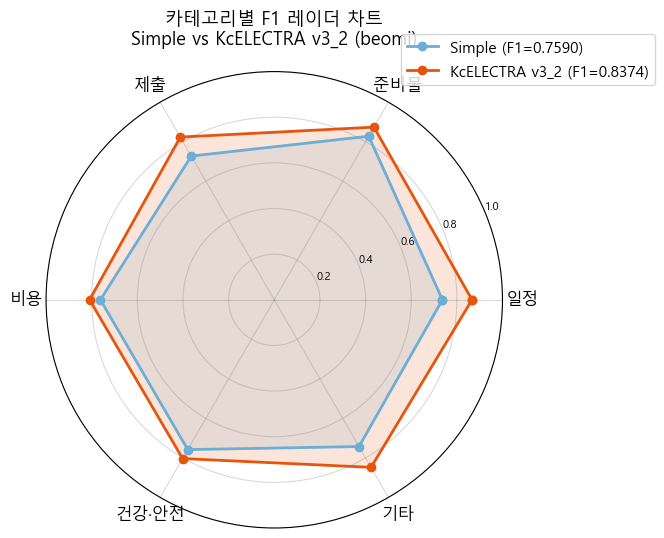

저장: C:\Users\kysop\Team_Project_Multiculture\multicultural-ai\model\classification\data\20260509\compare_radar_f1_v3_2_20260509.png


In [7]:
# 셀 5: [그래프 4] 레이더 차트

if kc is None:
    print("KcELECTRA 결과 없음 -- 스킵")
else:
    angles = np.linspace(0, 2 * np.pi, len(LABELS), endpoint=False).tolist()
    angles += angles[:1]

    s_vals = [simple["per_class"][lbl]["f1"] for lbl in LABELS] + [simple["per_class"][LABELS[0]]["f1"]]
    k_vals = [kc["per_class"][lbl]["f1"] for lbl in LABELS]     + [kc["per_class"][LABELS[0]]["f1"]]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    ax.plot(angles, s_vals, "o-", linewidth=2, color="#6baed6", label=f"Simple (F1={simple_f1:.4f})")
    ax.fill(angles, s_vals, alpha=0.15, color="#6baed6")

    ax.plot(angles, k_vals, "o-", linewidth=2, color="#e6550d", label=f"KcELECTRA v3_2 (F1={kc_f1:.4f})")
    ax.fill(angles, k_vals, alpha=0.15, color="#e6550d")

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(LABELS, fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8)
    ax.set_title("카테고리별 F1 레이더 차트\nSimple vs KcELECTRA v3_2 (beomi)",
                 fontsize=13, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=11)
    ax.grid(color="gray", alpha=0.3)

    plt.tight_layout()
    out_path = OUT / "compare_radar_f1_v3_2_20260509.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장: {out_path}")

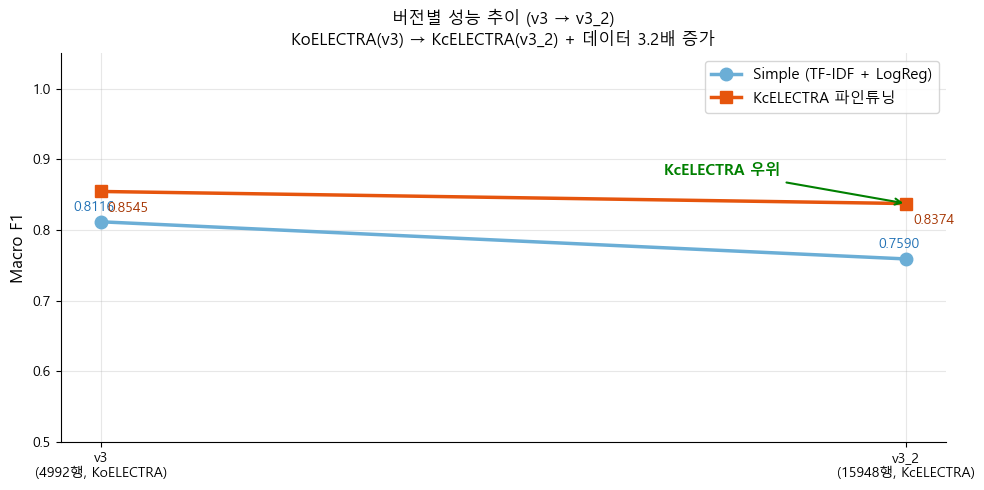

저장: C:\Users\kysop\Team_Project_Multiculture\multicultural-ai\model\classification\data\20260509\compare_version_trend_v3_2_20260509.png


In [ ]:
# 셀 6: [그래프 5] 버전별 성능 추이---> 수정 필요
# v3(KoELECTRA, v5 데이터) → v3_2(KcELECTRA, v3_1 데이터) 비교

# 과거 기록값 (devlog_2026-05-05 기준 — KoELECTRA 사용)
V3_SIMPLE_F1 = 0.8116   # v5 데이터 기준
V3_KC_F1     = 0.8545   # v5 데이터, KoELECTRA

# v3_1 Simple (새 데이터 기준)
V3_1_SIMPLE_F1 = 0.7590

# v3_2 현재값
V3_2_SIMPLE_F1 = simple_f1
V3_2_KC_F1     = kc_f1 if kc else None

fig, ax = plt.subplots(figsize=(10, 5))

versions    = ["v3\n(4992행, KoELECTRA)", "v3_2\n(15948행, KcELECTRA)"]
simple_hist = [V3_SIMPLE_F1, V3_2_SIMPLE_F1]

ax.plot(versions, simple_hist, "o-", color="#6baed6", linewidth=2.5,
        markersize=9, label="Simple (TF-IDF + LogReg)")

if V3_2_KC_F1 is not None:
    kc_hist = [V3_KC_F1, V3_2_KC_F1]
    ax.plot(versions, kc_hist, "s-", color="#e6550d", linewidth=2.5,
            markersize=9, label="KcELECTRA 파인튜닝")
    for x_pos, (s, k) in enumerate(zip(simple_hist, kc_hist)):
        ax.annotate(f"{s:.4f}", (x_pos, s), textcoords="offset points",
                    xytext=(-20, 8), fontsize=10, color="#2171b5")
        ax.annotate(f"{k:.4f}", (x_pos, k), textcoords="offset points",
                    xytext=(5, -15), fontsize=10, color="#a63603")
    if V3_2_KC_F1 > V3_2_SIMPLE_F1:
        ax.annotate("KcELECTRA 우위",
                    xy=(1, V3_2_KC_F1), xytext=(0.7, V3_2_KC_F1 + 0.04),
                    arrowprops=dict(arrowstyle="->", color="green", lw=1.5),
                    fontsize=11, color="green", fontweight="bold")
else:
    ax.plot([0], [V3_KC_F1], "s", color="#e6550d", markersize=9,
            label="KcELECTRA v3 (KoELECTRA, 구 데이터)")
    for x_pos, s in enumerate(simple_hist):
        ax.annotate(f"{s:.4f}", (x_pos, s), textcoords="offset points",
                    xytext=(-20, 8), fontsize=10, color="#2171b5")
    ax.text(1.0, 0.55, "KcELECTRA v3_2\n(Colab 결과 대기 중)",
            ha="center", fontsize=11, color="gray",
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

ax.set_ylim(0.5, 1.05)
ax.set_ylabel("Macro F1", fontsize=12)
ax.set_title("버전별 성능 추이 (v3 → v3_2)\nKoELECTRA(v3) → KcELECTRA(v3_2) + 데이터 3.2배 증가", fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
out_path = OUT / "compare_version_trend_v3_2_20260509.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"저장: {out_path}")

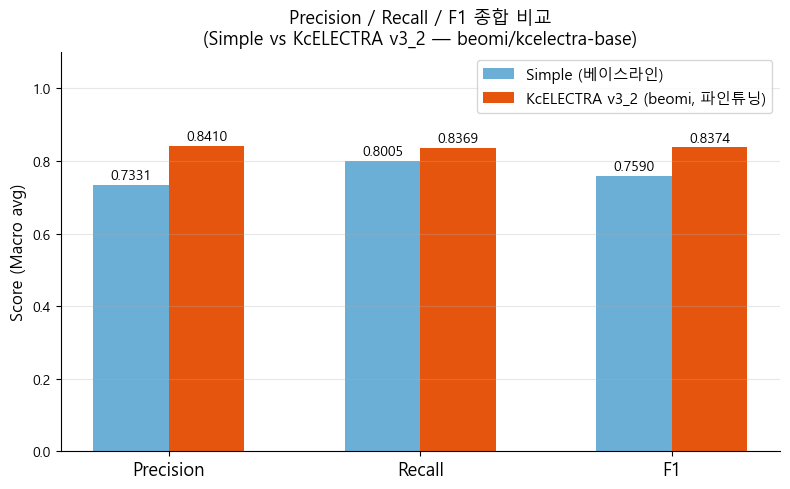

저장: C:\Users\kysop\Team_Project_Multiculture\multicultural-ai\model\classification\data\20260509\compare_precision_recall_f1_v3_2_20260509.png


In [9]:
# 셀 7: [그래프 6] Precision / Recall / F1 종합 비교

if kc is None:
    print("KcELECTRA 결과 없음 -- 스킵")
else:
    metrics = ["Precision", "Recall", "F1"]
    s_vals  = [simple["macro_precision"], simple["macro_recall"],  simple["macro_f1"]]
    k_vals  = [kc["macro_precision"],     kc["macro_recall"],      kc["macro_f1"]]

    x = np.arange(len(metrics))
    w = 0.3

    fig, ax = plt.subplots(figsize=(8, 5))
    bars1 = ax.bar(x - w/2, s_vals, w, label="Simple (베이스라인)", color="#6baed6")
    bars2 = ax.bar(x + w/2, k_vals, w, label="KcELECTRA v3_2 (beomi, 파인튜닝)", color="#e6550d")

    for bar in bars1:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                f"{h:.4f}", ha="center", va="bottom", fontsize=10)
    for bar in bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                f"{h:.4f}", ha="center", va="bottom", fontsize=10)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=13)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score (Macro avg)", fontsize=12)
    ax.set_title("Precision / Recall / F1 종합 비교\n(Simple vs KcELECTRA v3_2 — beomi/kcelectra-base)", fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    out_path = OUT / "compare_precision_recall_f1_v3_2_20260509.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장: {out_path}")

In [11]:
# 셀 8: 최종 요약 출력

#V3_SIMPLE_F1 = 0.8116
#V3_KC_F1     = 0.8545

print("=" * 65)
print("  최종 성능 비교 요약 (v3_1 데이터 — 15948행)")
print("  KcELECTRA v3_2: beomi/kcelectra-base")
print("=" * 65)
#print(f"  [참고] v3 Simple 베이스라인: {V3_SIMPLE_F1:.4f}  (v5 데이터 4992행, KoELECTRA 사용)")
#print(f"  [참고] v3 KcELECTRA:       {V3_KC_F1:.4f}  (실제로는 KoELECTRA였음)")
print()

if kc:
    print(f"  {'지표':15s} {'Simple v3_2':>14s} {'KcELECTRA v3_2':>16s} {'delta':>8s}")
    print("  " + "-" * 58)

    rows = [
        ("Macro Precision", simple["macro_precision"], kc["macro_precision"]),
        ("Macro Recall",    simple["macro_recall"],    kc["macro_recall"]),
        ("Macro F1",        simple["macro_f1"],        kc["macro_f1"]),
    ]
    for name, s, k_val in rows:
        d = k_val - s
        mark = "★" if d >= 0.05 else ("up" if d > 0 else "down")
        print(f"  {name:15s} {s:>14.4f} {k_val:>16.4f} {d:>+7.4f} {mark}")

    print("  " + "-" * 58)
    print(f"\n  {'카테고리':10s} {'Simple F1':>10s} {'KcELEC F1':>11s} {'delta':>7s}")
    print("  " + "-" * 44)
    for lbl in LABELS:
        s = simple["per_class"][lbl]["f1"]
        k_val = kc["per_class"][lbl]["f1"]
        d = k_val - s
        sup = kc["per_class"][lbl]["support"]
        mark = "up" if d > 0.02 else ("down" if d < -0.02 else "~")
        print(f"  {lbl:10s} {s:>10.4f} {k_val:>11.4f} {d:>+6.4f} {mark}  (test {int(sup)}건)")

    print("\n" + "=" * 65)
    delta_main = kc["macro_f1"] - simple_f1
    delta_v3   = kc["macro_f1"] - V3_SIMPLE_F1
    if delta_main >= 0.05:
        print(f"  결론: KcELECTRA v3_2 (beomi)이 Simple v3_2 대비 {delta_main:+.4f} (5%+ 달성!)")
    elif delta_main > 0:
        print(f"  결론: KcELECTRA v3_2 (beomi)이 Simple v3_2 대비 {delta_main:+.4f} 향상")
    else:
        print(f"  결론: Simple이 더 높음 (delta={delta_main:.4f}) — 재학습 필요")
    print(f"  (v3 Simple 기준 대비: {delta_v3:+.4f})")
    print("=" * 65)
else:
    print(f"  Simple v3_2 Macro F1: {simple_f1:.4f}")
    print(f"  KcELECTRA v3_2: 아직 미완료 (Colab 학습 필요)")
    print()
    print(f"  [v3_2 Simple 카테고리별 F1]")
    for lbl in LABELS:
        s = simple["per_class"][lbl]["f1"]
        sup = simple["per_class"][lbl]["support"]
        print(f"  {lbl:10s} {s:.4f}  (test {int(sup)}건)")
    print("=" * 65)

  최종 성능 비교 요약 (v3_1 데이터 — 15948행)
  KcELECTRA v3_2: beomi/kcelectra-base

  지표                 Simple v3_2   KcELECTRA v3_2    delta
  ----------------------------------------------------------
  Macro Precision         0.7331           0.8410 +0.1079 ★
  Macro Recall            0.8005           0.8369 +0.0364 up
  Macro F1                0.7590           0.8374 +0.0784 ★
  ----------------------------------------------------------

  카테고리        Simple F1   KcELEC F1   delta
  --------------------------------------------
  일정             0.7368      0.8665 +0.1297 up  (test 194건)
  준비물            0.8276      0.8736 +0.0460 up  (test 44건)
  제출             0.7273      0.8233 +0.0960 up  (test 316건)
  비용             0.7619      0.8095 +0.0476 up  (test 84건)
  건강·안전          0.7581      0.8034 +0.0453 up  (test 214건)
  기타             0.7426      0.8479 +0.1053 up  (test 741건)

  결론: KcELECTRA v3_2 (beomi)이 Simple v3_2 대비 +0.0784 (5%+ 달성!)
  (v3 Simple 기준 대비: +0.0258)
